# Calculate geometric eigenmodes

As outlined in in [Pang *et al.* (2023)](https://doi.org/10.1038/s41586-023-06098-1), the geometric
 eigenmodes of a brain structure can be obtained by solving the Laplace-Beltrami eigenvalue problem,

$$
\displaystyle \Delta\Psi = -\Lambda\Psi,
$$
 
 where:
 - $\Delta$ denotes the Laplace-Beltrami operator
 - $\Psi$ denotes the set of eigenmodes $\{\psi _1, \psi _2, ...\}$, ordered in ascending spatial frequency
 - $\Lambda$ denotes the set of eigenvalues $\{\lambda _1, \lambda _2, ...\}$, ordered in increasing value

In representing a brain structure as a discrete mesh of $N$ vertices, the above relation becomes a
 generalized eigenvalue problem,

$$
\displaystyle K\Psi = -\Lambda M\Psi,
$$

 where $K$ and $M$ denote the mass and stiffness matrices used by the Finite Element Method.

To calculate geometric eigenmodes of the cortex, we will first initialise an `EigenSolver` with a
 triangular surface mesh and medial wall mask. Since `neuromodes` includes these for human, macaque,
 and marmoset cortices, we can provide them as follows:

In [1]:
from importlib.resources import files, as_file
from nsbutils.plotting import plot_surf
from neuromodes import EigenSolver
from neuromodes.io import fetch_surf
from neuromodes.mesh import unmask_data

# Load cortical surface mesh
surf, medmask = fetch_surf()

# Initialise solver with surface
solver = EigenSolver(surf, mask=medmask)

Note that by default, `fetch_surf` will load the human left hemisphere fsLR-32k midthickness
surface.

Next, we can compute eigenmodes and eigenvalues:

In [2]:
solver.solve(100)
print(solver)

EigenSolver
-----------
Surface mesh: 29696 vertices (2796 others masked out), 59147 triangles
100 eigenmodes computed



Note that we specified the first 100 eigenmodes and eigenvalues, which are then stored in the
 `emodes` and `evals` attributes. To visualize the modes, we can first add our medial wall back in
 via `unmask_data`, then pass a few modes to a plotter, such as `plot_surf` from our sister package
 `nsbutils`:

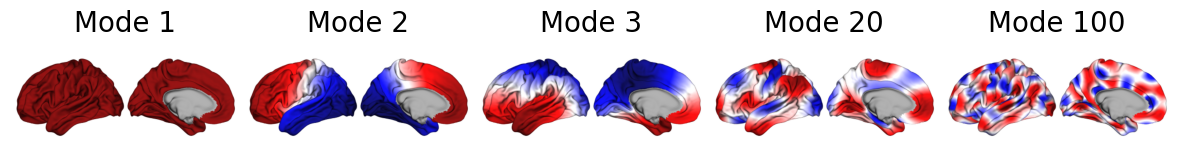

In [3]:
modes_unmasked = unmask_data(solver.emodes, medmask)

lh_surfpath = files('neuromodes.data') / 'sp-human_tpl-fsLR_den-32k_hemi-L_midthickness.surf.gii'
with as_file(lh_surfpath) as lh_surfpath:
    plot_surf(lh_surfpath, modes_unmasked[:,[0,1,2,19,99]], labels=['Mode 1', 'Mode 2', 'Mode 3', 'Mode 20', 'Mode 100'], cmap='seismic_r')